In [1]:
%matplotlib inline

# Fractionation - Exercise

Take the following process from [this example](https://cadet-process.readthedocs.io/en/stable/examples/load_wash_elute/lwe_flow_rate.html).

- Simulate the process.
- Plot the outlet concentration. Use a secondary axis for the `Salt` component.
- Instantiate a `Fractionator` and manually set fractionation times to purify component `C`.
- Plot the results and analyse the `performance`, especially the purity.
- Exclude the `Salt` component from the fractionation and analyse the `performance` again.
- Use a `FractionationOptimizer` to automatically determine adequate cut times. Play around with different purity requirements and objecives.

In [2]:
from examples.load_wash_elute.lwe_flow_rate import process

(<Figure size 354.331x236.22 with 2 Axes>,
 (<Axes: xlabel='$Time~/~\\text{min}$', ylabel='$c~/~\\text{mM}$'>,
  <Axes: ylabel='$c_{salt}$'>))

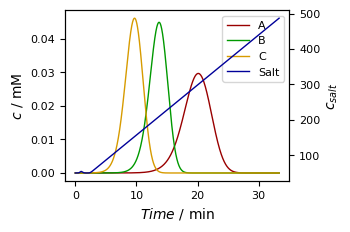

In [3]:
from CADETProcess.simulator import Cadet

simulator = Cadet()

simulation_results = simulator.simulate(process)

from CADETProcess.plotting import SecondaryAxis
sec = SecondaryAxis(
    components=["Salt"],
    ylabel="$c_{salt}$",
)

simulation_results.solution.outlet.inlet.plot(secondary_axes=sec)

[WARNING 03-30 22:29:51] ax.storage.sqa_store.with_db_settings_base: Ax currently requires a sqlalchemy version below 2.0. This will be addressed in a future release. Disabling SQL storage in Ax for now, if you would like to use SQL storage please install Ax with mysql extras via `pip install ax-platform[mysql]`.


Performance(mass=array([0.00000000e+00, 0.00000000e+00, 1.11645997e-09, 0.00000000e+00]), concentration=array([0.0000000e+00, 0.0000000e+00, 9.2800691e-05, 0.0000000e+00]), purity=array([0.00000000e+00, 0.00000000e+00, 8.62500409e-07, 0.00000000e+00]), recovery=array([0.        , 0.        , 0.00167041, 0.        ]), productivity=array([0.00000000e+00, 0.00000000e+00, 8.05850899e-07, 0.00000000e+00]), eluent_consumption=array([0.00000000e+00, 0.00000000e+00, 8.39403235e-06, 0.00000000e+00]) mass_balance_difference=array([ 3.37316524e-02,  2.03691260e-13,  1.27515399e-13, -1.46383649e-14]))

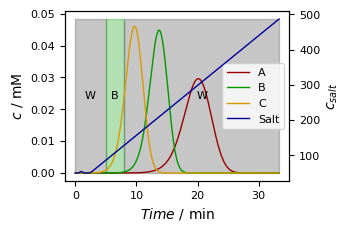

In [4]:
from CADETProcess.fractionation import Fractionator
fractionator = Fractionator(simulation_results)

fractionator.add_fractionation_event('start_C', 2, 5*60)
fractionator.add_fractionation_event('end_C', -1, 8*60)

fractionator.plot_fraction_signal(secondary_axes=sec)
fractionator.performance

Performance(mass=array([6.24584476e-11, 0.00000000e+00, 0.00000000e+00]), concentration=array([5.19157628e-06, 0.00000000e+00, 0.00000000e+00]), purity=array([0.00062625, 0.        , 0.        ]), recovery=array([9.3448373e-05, 0.0000000e+00, 0.0000000e+00]), productivity=array([4.50819532e-08, 0.00000000e+00, 0.00000000e+00]), eluent_consumption=array([4.69589814e-07, 0.00000000e+00, 0.00000000e+00]) mass_balance_difference=array([ 2.03691260e-13,  1.27515399e-13, -1.46383649e-14]))

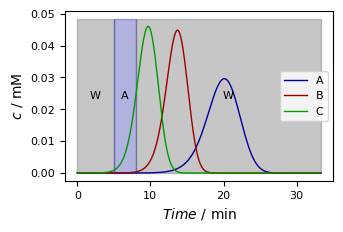

In [5]:
fractionator = Fractionator(simulation_results, components=['A', 'B', 'C'])

fractionator.add_fractionation_event('start_C', 0, 5*60)
fractionator.add_fractionation_event('end_C', -1, 8*60)

fractionator.plot_fraction_signal()
fractionator.performance

Performance(mass=array([0.00000000e+00, 0.00000000e+00, 5.28357629e-07]), concentration=array([0.        , 0.        , 0.01388162]), purity=array([0.        , 0.        , 0.94543794]), recovery=array([0.        , 0.        , 0.79051214]), productivity=array([0.        , 0.        , 0.00038136]), eluent_consumption=array([0.        , 0.        , 0.00397242]) mass_balance_difference=array([2.26531601e-13, 5.62946849e-14, 2.41113183e-14]))


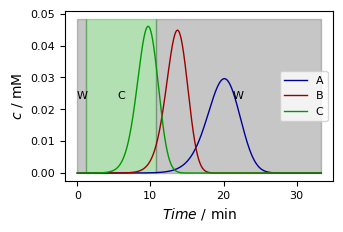

In [6]:
from CADETProcess.fractionation import FractionationOptimizer
fractionation_optimizer = FractionationOptimizer()

fractionator = fractionation_optimizer.optimize_fractionation(
    simulation_results,
    components=['A', 'B', 'C'],
    purity_required=[0, 0, 0.95]
)
print(fractionator.performance)
_ = fractionator.plot_fraction_signal()